In [1]:
import numpy as np
import emcee 
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm

In [2]:
transient = np.load('transient.npy')
time = transient[:, 0]
flux = transient[:, 1]
errs = transient[:, 2]

N = len(time)

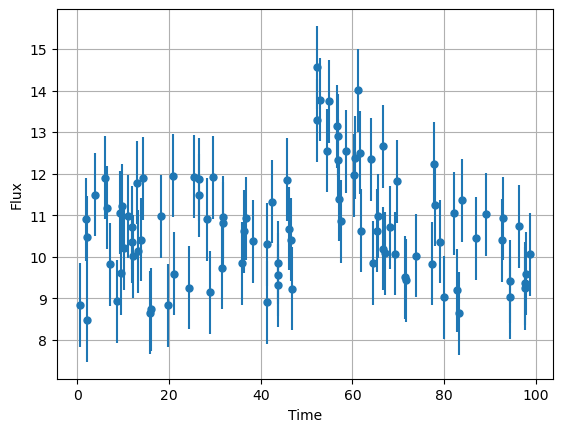

In [3]:
fig, ax = plt.subplots()
plt.errorbar(x=time, y=flux, yerr=errs, fmt='o', markersize=5)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.grid()

In [42]:
def model(t, b, t0, A, alpha):

    y = np.zeros(len(t))
    cond = (t < t0)

    y[cond] += b
    y[~cond] += b + A*np.exp(-alpha*(t[~cond]-t0))
    
    return y

In [43]:
def log_lik(params, times, data, err):
    b, t0, A, logalpha = params 
    alpha = np.exp(logalpha)
    modely = model(times, b, t0, A, alpha)
    
    loglik = np.sum(-((data-modely) / err)**2 - 1/2*np.log(2 * np.pi * err**2))
    return loglik

In [44]:
# all the priors are uniform between these ranges:
# b and A between 0 and 50
# t0 between 0 and 100
# log(alpha) between -5 and 5

def log_prior(params):
    
    b, t0, A, logalpha = params 
    
    condb = (b >= 0) and (b <= 50)
    condA = (A >= 0) and (A <= 50)
    condt = (t0 >= 0) and (t0 <= 100)
    condalph = (logalpha >= -5) and (logalpha <= 5)

    if condb and condA and condt and condalph:
        return np.log(1/50) * 2 + np.log(1/100) + np.log(1/10)

    else: 
        return -np.inf

def log_post(params, times, data, err):
    # posterior = likelihood * prior
    lp = log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
        
    return log_lik(params, times, data, err) + lp

# Using emcee

In [45]:
nsteps = 50000
nparam = 4
nwalkers = 10

starting_guesses = np.zeros((nwalkers, nparam))
starting_guesses[:, 0] = np.random.uniform(0, 50, nwalkers)
starting_guesses[:, 1] = np.random.uniform(0, 50, nwalkers)
starting_guesses[:, 2] = np.random.uniform(0, 100, nwalkers)
starting_guesses[:, 3] = np.random.uniform(-5, 5, nwalkers)

sampler = emcee.EnsembleSampler(nwalkers, nparam, log_post, args=[time, flux, errs])
sampler.run_mcmc(starting_guesses, nsteps)

State([[10.17688407 51.98890515  3.47522067 -2.29365199]
 [10.34084222 47.51149252  6.81440546 -1.90343946]
 [10.32921255 50.70810166  4.58620694 -2.07758276]
 [10.23122226 47.12010859  5.76992581 -2.34481401]
 [10.17419081 51.82470166  4.08370967 -2.29375883]
 [10.21790791 50.20206825  4.44350356 -2.24617192]
 [10.28452466 50.58934451  4.18814362 -2.15565175]
 [10.22929465 50.0151321   5.95747669 -1.98264286]
 [10.29795443 47.89741954  6.17939523 -2.04729369]
 [10.24799607 47.01913262  6.02647749 -2.30380009]], log_prob=[-205.98769243 -207.6591117  -204.26230579 -205.1689564  -205.52079023
 -204.72608412 -204.70080946 -205.78984418 -205.09496249 -204.808735  ], blobs=None, random_state=('MT19937', array([1131398013, 1655810460, 2618382737, 2193229310, 2295060749,
        152523836, 1567358595, 1367812046, 2697059313, 2874746760,
        335170016,  485489300,  271277602, 3641558595, 2646328127,
       1689338654, 1385255450, 3176994471, 1092491252, 3122210921,
       3108444111, 29537

In [46]:
burn = 5000
tau = sampler.get_autocorr_time()
thin = np.ones(len(tau))
for i in range(len(tau)):
    thin[i] = int(tau[i]+1)

# thin = int(tau+1)

# trace = sampler.get_chain(discard=burn, thin=thin, flat=True).flatten()

# b_trace = trace[:, 0]
# t0_trace = trace[:, 1]
# A_trace = trace[:, 2]
# logalph_trace = trace[:, 3]

# fig, ax = plt.subplots()
# plt.plot(b_trace, label='b')
# plt.legend()

print(tau)

[ 151.94432843  855.159624   1600.98254536 2102.19255776]


C:\Users\perri\anaconda3\envs\New_env_for_fun\Lib\site-packages\IPython\core\events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\perri\anaconda3\envs\New_env_for_fun\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


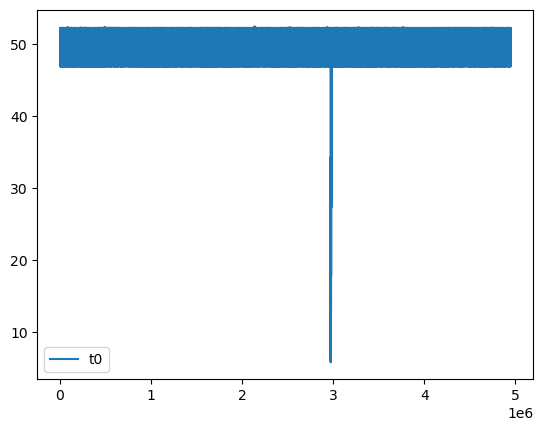

In [29]:
plt.plot(t0_trace, label='t0')

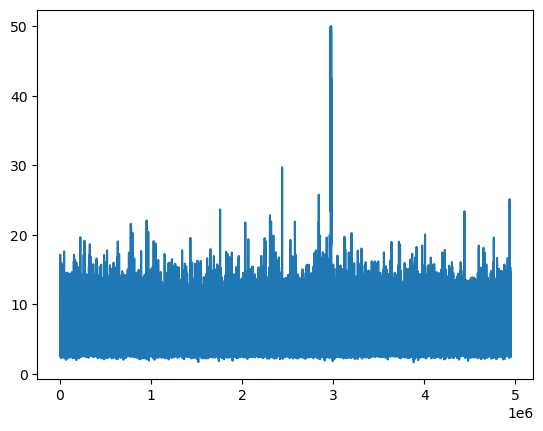

In [30]:
plt.plot(A_trace, label='A')


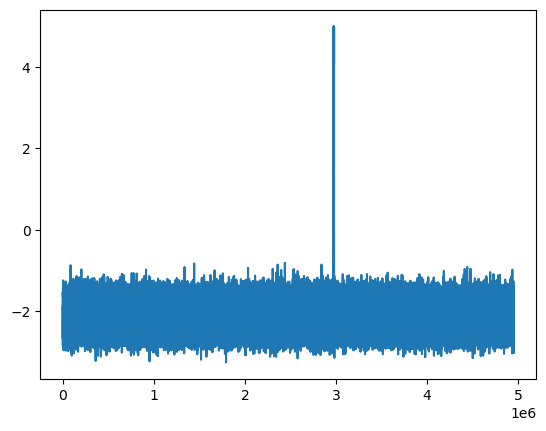

In [31]:
plt.plot(logalph_trace, label='logalpha')

# Using nested sampling